# Pearson-Korrelation – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/pearson-korrelation)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **Pearson-Korrelation** (Produkt-Moment-Korrelation) misst den
**linearen Zusammenhang** zwischen zwei metrischen Variablen.

**Formel:**
$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n(x_i-\bar{x})^2 \cdot \sum_{i=1}^n(y_i-\bar{y})^2}}$$

**Signifikanztest:**
$$t = r \cdot \sqrt{\frac{n-2}{1-r^2}}, \quad df = n-2$$

**Stärke des Zusammenhangs:**

| |r| | Korrelation |
|---|---|
| 0,0 – 0,1 | Keine |
| 0,1 – 0,3 | Gering |
| 0,3 – 0,5 | Mittel |
| 0,5 – 0,7 | Hoch |
| 0,7 – 1,0 | Sehr hoch |

**Voraussetzungen:**
- Beide Variablen **metrisch** (für r allein)
- Beide Variablen **normalverteilt** (für Signifikanztest!)
- **Linearer** Zusammenhang (kein kurvilinearer)
- Bei Verletzung → **Spearman-Korrelation**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, shapiro

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Alter und Gehalt

**Fragestellung:** Gibt es einen Zusammenhang zwischen Alter und Gehalt?

Für dieses Notebook verwenden wir das Körpergröße-Gewicht-Beispiel aus dem
Korrelations-Tutorial (selbe Formel, selbe Berechnung):

| Körpergröße (m) | 1,62 | 1,72 | 1,85 | 1,82 | 1,72 | 1,55 | 1,65 | 1,77 | 1,83 | 1,53 |
|---|---|---|---|---|---|---|---|---|---|---|
| **Gewicht (kg)** | 53 | 71 | 85 | 86 | 76 | 62 | 68 | 77 | 97 | 65 |

**Erwartetes numiqo-Ergebnis:** r(8) = 0,86, p = 0,001

In [20]:
# numiqo-Datensatz
groesse = np.array([1.62, 1.72, 1.85, 1.82, 1.72, 1.55, 1.65, 1.77, 1.83, 1.53])
gewicht = np.array([53, 71, 85, 86, 76, 62, 68, 77, 97, 65], dtype=float)
n = len(groesse)

# Pearson manuell
x_c  = groesse - groesse.mean()
y_c  = gewicht - gewicht.mean()
zaehler = (x_c * y_c).sum()
nenner  = np.sqrt((x_c**2).sum() * (y_c**2).sum())
r_man   = zaehler / nenner
t_man   = r_man * np.sqrt((n-2) / (1 - r_man**2))
p_man   = 2 * stats.t.sf(abs(t_man), df=n-2)

r_sci, p_sci = pearsonr(groesse, gewicht)

print("Pearson-Korrelation: Körpergröße x Gewicht")
print("r = " + str(round(r_man, 4)) + "  (numiqo: 0,86)")
print("t(" + str(n-2) + ") = " + str(round(t_man, 4)))
print("p = " + str(round(p_man, 4)) + "  (numiqo: 0,001)")
print()
print("Kontrolle scipy: r=" + str(round(r_sci, 4)) + "  p=" + str(round(p_sci, 4)))
print()

def interpret_r(r):
    ar = abs(r)
    if ar < 0.1: return "keine Korrelation"
    elif ar < 0.3: return "geringe Korrelation"
    elif ar < 0.5: return "mittlere Korrelation"
    elif ar < 0.7: return "hohe Korrelation"
    return "sehr hohe Korrelation"

richtung = "positive" if r_sci > 0 else "negative"
print("Interpretation: r=" + str(round(r_sci, 3)) +
      " -> " + interpret_r(r_sci) + " (" + richtung + ")")
print()
print("APA: r(8) = 0.86, p = .001")
print("Signifikant! Es gibt einen sehr hohen positiven Zusammenhang.")

Pearson-Korrelation: Körpergröße x Gewicht
r = 0.86  (numiqo: 0,86)
t(8) = 4.7667
p = 0.0014  (numiqo: 0,001)

Kontrolle scipy: r=0.86  p=0.0014

Interpretation: r=0.86 -> sehr hohe Korrelation (positive)

APA: r(8) = 0.86, p = .001
Signifikant! Es gibt einen sehr hohen positiven Zusammenhang.


## 2. Geometrische Intuition: Quadranten

Der Pearson-r ergibt sich aus den **Produkten der zentrierten Werte**.

- Punkt im **rechten oberen** Quadrant (x > x̄, y > ȳ) → positives Produkt → **positiver Beitrag**
- Punkt im **linken unteren** Quadrant (x < x̄, y < ȳ) → negatives × negatives = **positiver Beitrag**
- Punkt im **rechten unteren** oder **linken oberen** Quadrant → **negativer Beitrag**

Überwiegen positive Beiträge → r > 0 (positiver Zusammenhang)

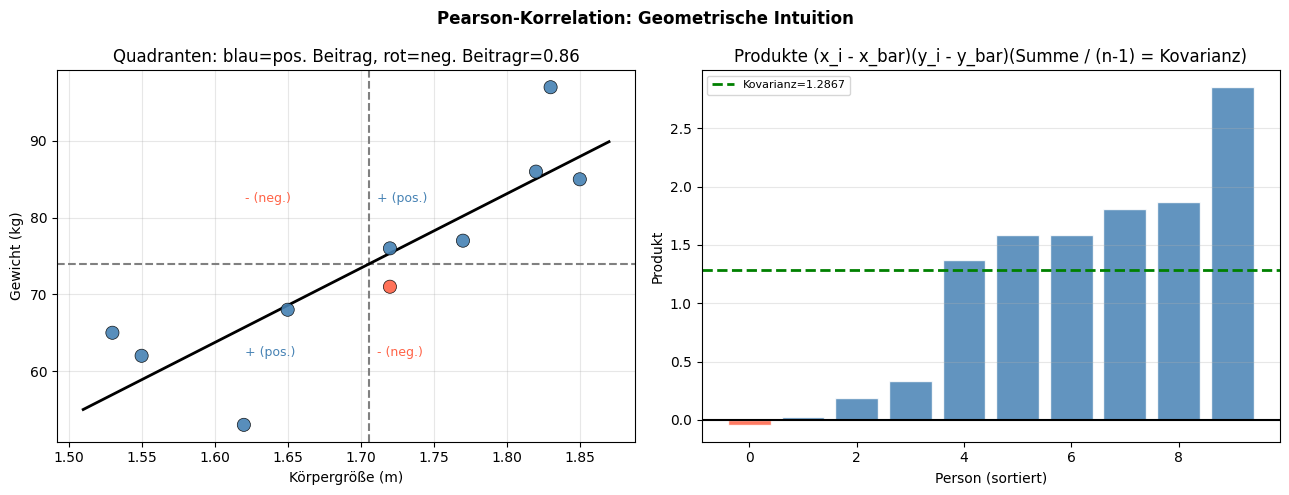

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Pearson-Korrelation: Geometrische Intuition",
             fontsize=12, fontweight="bold")

# 1. Streudiagramm mit Quadranten
x_m, y_m = groesse.mean(), gewicht.mean()
farben_q = []
for g, w in zip(groesse, gewicht):
    produkt = (g - x_m) * (w - y_m)
    farben_q.append("steelblue" if produkt > 0 else "tomato")

axes[0].scatter(groesse, gewicht, c=farben_q, s=90, alpha=0.9, zorder=3,
                edgecolors="black", linewidth=0.5)
axes[0].axvline(x_m, color="gray", linestyle="--", linewidth=1.5)
axes[0].axhline(y_m, color="gray", linestyle="--", linewidth=1.5)

# Quadranten beschriften
axes[0].text(x_m + 0.005, y_m + 8,  "+ (pos.)", color="steelblue", fontsize=9)
axes[0].text(x_m - 0.085, y_m + 8,  "- (neg.)", color="tomato",    fontsize=9)
axes[0].text(x_m + 0.005, y_m - 12, "- (neg.)", color="tomato",    fontsize=9)
axes[0].text(x_m - 0.085, y_m - 12, "+ (pos.)", color="steelblue", fontsize=9)

# Regressionsgerade
m_r, b_r = np.polyfit(groesse, gewicht, 1)
x_l = np.linspace(groesse.min()-0.02, groesse.max()+0.02, 100)
axes[0].plot(x_l, m_r*x_l + b_r, color="black", linewidth=2)
axes[0].set_title("Quadranten: blau=pos. Beitrag, rot=neg. Beitragr=" +
                  str(round(r_sci, 3)))
axes[0].set_xlabel("Körpergröße (m)")
axes[0].set_ylabel("Gewicht (kg)")
axes[0].grid(alpha=0.3)

# 2. Produkte je Datenpunkt als Balken
produkte = x_c * y_c
idx_sort = np.argsort(produkte)
farben_b = ["steelblue" if p > 0 else "tomato" for p in produkte[idx_sort]]
axes[1].bar(range(n), produkte[idx_sort], color=farben_b, edgecolor="white", alpha=0.85)
axes[1].axhline(0, color="black", linewidth=1.5)
axes[1].axhline(produkte.sum()/(n-1), color="green", linestyle="--", linewidth=2,
                label="Kovarianz=" + str(round(produkte.sum()/(n-1), 4)))
axes[1].set_title("Produkte (x_i - x_bar)(y_i - y_bar)(Summe / (n-1) = Kovarianz)")
axes[1].set_xlabel("Person (sortiert)")
axes[1].set_ylabel("Produkt")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Voraussetzungen prüfen

**Für r allein:** Nur metrische Variablen nötig.

**Für Signifikanztest:** Beide Variablen müssen normalverteilt sein!
Prüfung mit Shapiro-Wilk und Q-Q-Plot.

Normalverteilungsprüfung (Shapiro-Wilk)
Körpergröße: W=0.9301  p=0.449 -> NV angenommen
Gewicht:        W=0.9882  p=0.9941 -> NV angenommen

-> Pearson-Korrelation zulässig!


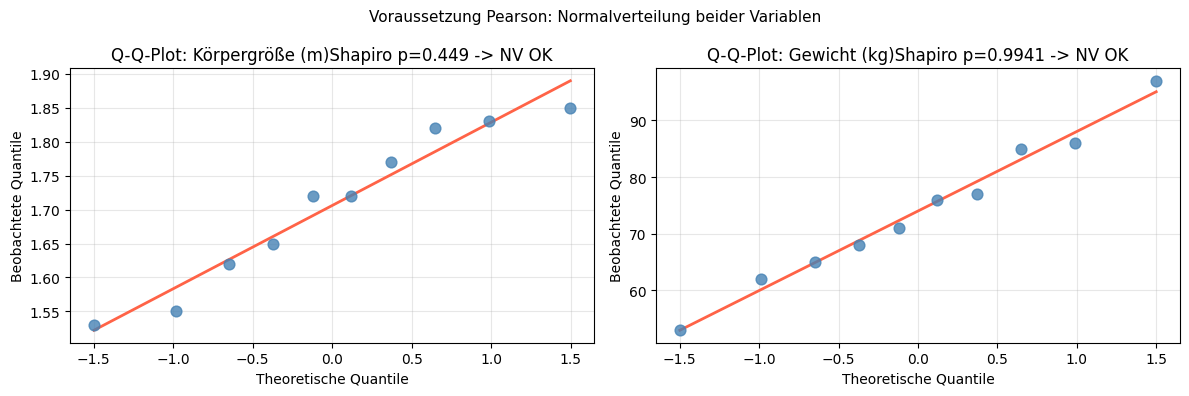

In [27]:
# Voraussetzungen prüfen
w_x, p_x = shapiro(groesse)
w_y, p_y = shapiro(gewicht)

print("Normalverteilungsprüfung (Shapiro-Wilk)")
print("Körpergröße: W=" + str(round(w_x, 4)) + "  p=" + str(round(p_x, 4)) +
      " -> " + ("NV angenommen" if p_x > 0.05 else "NICHT NV"))
print("Gewicht:        W=" + str(round(w_y, 4)) + "  p=" + str(round(p_y, 4)) +
      " -> " + ("NV angenommen" if p_y > 0.05 else "NICHT NV"))
print()
if p_x > 0.05 and p_y > 0.05:
    print("-> Pearson-Korrelation zulässig!")
else:
    print("-> NV nicht gegeben -> Spearman verwenden!")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Voraussetzung Pearson: Normalverteilung beider Variablen",
             fontsize=11)

for ax, (daten, name, p_sw) in zip(axes, [
    (groesse, "Körpergröße (m)", p_x),
    (gewicht, "Gewicht (kg)", p_y)
]):
    (osm, osr), (slope, intercept, _) = stats.probplot(daten, dist="norm")
    y_fit = slope * osm + intercept
    ax.scatter(osm, osr, color="steelblue", s=60, alpha=0.8, zorder=3)
    ax.plot(osm, y_fit, color="tomato", linewidth=2)
    ax.set_title("Q-Q-Plot: " + name +
                 "Shapiro p=" + str(round(p_sw, 4)) +
                 " -> " + ("NV OK" if p_sw > 0.05 else "nicht NV"))
    ax.set_xlabel("Theoretische Quantile")
    ax.set_ylabel("Beobachtete Quantile")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Schritt-für-Schritt-Berechnung

1. Mittelwerte $\bar{x}$, $\bar{y}$ berechnen
2. Zentrierte Werte $(x_i - \bar{x})$ und $(y_i - \bar{y})$
3. Produkte bilden und summieren → Zähler
4. Quadrate summieren → Nenner
5. $r = $ Zähler / Nenner
6. $t = r \cdot \sqrt{(n-2)/(1-r^2)}$ → p-Wert

In [25]:
print("Schritt-für-Schritt: Pearson-Korrelation")
print()
print("i   Größe  Gewicht  x-x_bar  y-y_bar  Produkt    (x-x_b)^2  (y-y_b)^2")
for i, (g, w, xc, yc) in enumerate(zip(groesse, gewicht, x_c, y_c)):
    prod = xc * yc
    print(str(i+1) + "   " + str(g) + "    " + str(int(w)) +
          "    " + str(round(xc, 4)) + "  " + str(round(yc, 2)) +
          "   " + str(round(prod, 4)) + "   " + str(round(xc**2, 6)) +
          "   " + str(round(yc**2, 2)))
print()
print("Zähler    = Sum[(x-x_bar)(y-y_bar)] = " + str(round(zaehler, 4)))
print("Sum(x-x_bar)^2 = " + str(round((x_c**2).sum(), 6)))
print("Sum(y-y_bar)^2 = " + str(round((y_c**2).sum(), 2)))
print("Nenner    = sqrt(" + str(round((x_c**2).sum(), 6)) +
      " * " + str(round((y_c**2).sum(), 2)) + ") = " + str(round(nenner, 4)))
print()
print("r = " + str(round(zaehler, 4)) + " / " + str(round(nenner, 4)) +
      " = " + str(round(r_man, 4)) + "  (numiqo: 0.86)")
print()
print("t = " + str(round(r_man, 4)) + " * sqrt((" + str(n) + "-2)/(1-" +
      str(round(r_man**2, 4)) + "))")
print("t = " + str(round(t_man, 4)) + "  p=" + str(round(p_man, 4)))

Schritt-für-Schritt: Pearson-Korrelation

i   Größe  Gewicht  x-x_bar  y-y_bar  Produkt    (x-x_b)^2  (y-y_b)^2
1   1.62    53    -0.086  -21.0   1.806   0.007396   441.0
2   1.72    71    0.014  -3.0   -0.042   0.000196   9.0
3   1.85    85    0.144  11.0   1.584   0.020736   121.0
4   1.82    86    0.114  12.0   1.368   0.012996   144.0
5   1.72    76    0.014  2.0   0.028   0.000196   4.0
6   1.55    62    -0.156  -12.0   1.872   0.024336   144.0
7   1.65    68    -0.056  -6.0   0.336   0.003136   36.0
8   1.77    77    0.064  3.0   0.192   0.004096   9.0
9   1.83    97    0.124  23.0   2.852   0.015376   529.0
10   1.53    65    -0.176  -9.0   1.584   0.030976   81.0

Zähler    = Sum[(x-x_bar)(y-y_bar)] = 11.58
Sum(x-x_bar)^2 = 0.11944
Sum(y-y_bar)^2 = 1518.0
Nenner    = sqrt(0.11944 * 1518.0) = 13.4651

r = 11.58 / 13.4651 = 0.86  (numiqo: 0.86)

t = 0.86 * sqrt((10-2)/(1-0.7396))
t = 4.7667  p=0.0014


## 5. Bedeutung von n: Wann ist r signifikant?

Derselbe r-Wert kann bei kleinem n nicht signifikant sein, bei großem n schon.
**Je größer die Stichprobe, desto sensitiver der Test.**

n=5:  r_min=0.8783  (r=0.88 gerade noch sig.)
n=10:  r_min=0.6319  (r=0.63 gerade noch sig.)
n=20:  r_min=0.4438  (r=0.44 gerade noch sig.)
n=30:  r_min=0.361  (r=0.36 gerade noch sig.)
n=50:  r_min=0.2787  (r=0.28 gerade noch sig.)
n=100:  r_min=0.1966  (r=0.2 gerade noch sig.)
n=200:  r_min=0.1388  (r=0.14 gerade noch sig.)


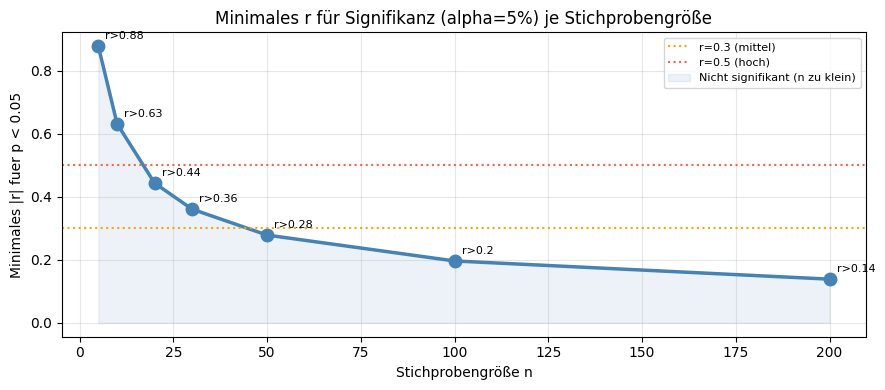

In [ ]:
# Minimales r für Signifikanz je n
n_werte = [5, 10, 20, 30, 50, 100, 200]
r_min   = []
alpha   = 0.05

for n_s in n_werte:
    # t_krit bei alpha/2, df=n-2
    t_krit = stats.t.ppf(1 - alpha/2, df=n_s-2)
    # r_min aus t = r*sqrt((n-2)/(1-r^2)) -> r^2 = t^2/(t^2+n-2)
    r_m = np.sqrt(t_krit**2 / (t_krit**2 + n_s - 2))
    r_min.append(r_m)
    print("n=" + str(n_s) + ":  r_min=" + str(round(r_m, 4)) +
          "  (r=" + str(round(r_m, 2)) + " gerade noch sig.)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_werte, r_min, "o-", color="steelblue", linewidth=2.5, markersize=9)
ax.axhline(0.3, color="orange", linestyle=":", linewidth=1.5, label="r=0.3 (mittel)")
ax.axhline(0.5, color="tomato",  linestyle=":", linewidth=1.5, label="r=0.5 (hoch)")
ax.fill_between(n_werte, 0, r_min, alpha=0.1, color="steelblue",
                label="Nicht signifikant (n zu klein)")
for n_s, rm in zip(n_werte, r_min):
    ax.annotate("r>" + str(round(rm, 2)), (n_s, rm),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_title("Minimales r für Signifikanz (alpha=5%) je Stichprobengröße")
ax.set_xlabel("Stichprobengröße n")
ax.set_ylabel("Minimales |r| für p < 0.05")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Zusammenfassung

```
Pearson-Korrelation – Übersicht
│
├── WAS?
│   Mass des LINEAREN Zusammenhangs zwischen 2 metrischen Variablen
│   r in [-1, +1]: +1 perfekt positiv, -1 perfekt negativ, 0 kein Zshg.
│
├── FORMEL
│   r = Sum[(xi-x_bar)(yi-y_bar)] / sqrt(Sum(xi-x_bar)^2 * Sum(yi-y_bar)^2)
│   Intuition: Mittleres Produkt der zentrierten und normierten Werte
│
├── SIGNIFIKANZTEST
│   t = r * sqrt((n-2)/(1-r^2)),  df = n-2
│   H0: r = 0 (kein lin. Zusammenhang in GG)
│   H1: r != 0
│
├── VORAUSSETZUNGEN
│   Für r allein:         Beide Variablen metrisch
│   Für Signifikanztest:  Beide Variablen NORMALVERTEILT
│                          Linearer (nicht kurvilinearer) Zusammenhang
│   Bei Verletzung:        Spearman-Korrelation
│
├── STAÄKE-INTERPRETATION (Kuckartz 2013)
│   |r| < 0.1:  keine
│   0.1 - 0.3:  gering
│   0.3 - 0.5:  mittel
│   0.5 - 0.7:  hoch
│   0.7 - 1.0:  sehr hoch
│
├── numiqo-BEISPIEL: Körpergröße x Gewicht
│   r(8) = 0.86, p = .001 -> sehr hohe positive Korrelation
│
└── PYTHON
    from scipy.stats import pearsonr
    r, p = pearsonr(x, y)
```

---
Quelle: [numiqo.de/tutorial/pearson-korrelation](https://numiqo.de/tutorial/pearson-korrelation)